> Can a simple encoder learn "soft-separable" pitch vs time directions in latent space? An alternative to explicit factorization

<div style="text-align: right; margin: 0;">
<a href="https://colab.research.google.com/drive/1FfCAirGj3AP_SlRTSLqEip26TtmuYfqv?usp=sharing" target="_">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="display: inline-block;"/></a>
</div>


**Idea**: Apply pitch-shifts and time-shifts to random blob images. Train a small ConvNet encoder
with a cosine-similarity loss that enforces:
- Same-type, same-sign shifts → **parallel** difference vectors (target +1)
- Same-type, opposite-sign shifts → **anti-parallel** difference vectors (target −1)
- Cross-type shifts → **orthogonal** difference vectors (target 0)

As shown below, PCA of the difference vectors reveals a clear cross pattern with pitch and time axes separating cleanly, and cosine similarity histograms confirm the desired geometric relationships.

::: {.callout-note}
Some prose in this post was drafted with LLM assistance and edited by hand.
:::

## TL;DR

We exploit the fact that pitch-shifts and time-shifts are explicitly labeled augmentations, and use those labels to encode the operations geometrically via a loss function. Add this to an encoder and see if it achieves a **soft factorization** of pitch and time:

```python
def factorization_loss(z_anchor, z_crop1, z_crop2, targets):
    d1 = z_crop1 - z_anchor
    d2 = z_crop2 - z_anchor
    cos = F.cosine_similarity(d1, d2, dim=-1)
    return ((cos - targets) ** 2).mean()
```

where `targets` are +1 (same-type, same-sign), −1 (same-type, opposite-sign), or 0 (cross-type):



![Figure 1: Our loss enforces differences between pairs of embeddings to either be parallel, anti-parallel, or orthogonal, depending on the type of data augmentation.](images/soft_sep_diagram.png)



(We do not specify these directions. We simply enforce parallel, anti-parallel, or orthogonal, and let the system evolve on its own.)

**Spoiler: it works.** Since this toy model succeeds (as shown below), we will have confidence to move on and apply it to a "real" problem with real MIDI data.

## Motivation

### Why factorize pitch and time?

Much of the variety within a song comes from repeating melodic patterns (pitch) and rhythmic patterns (time), which suggests a natural decomposition into a **pitch vocabulary** and a **rhythm vocabulary**, where a motif can be approximated as an interaction (outer product) of pitch and time components. Factored representations are also connected to compositional algebraic properties — **GloVe** word vectors (Pennington et al., 2014) demonstrated that vector arithmetic (e.g., *king − man + woman ≈ queen*) arose from GloVe's explicitly factorized construction of word co-occurrence matrices.

### Why soft factorization?

Prior work (MelodyGLM, Music SketchNet, PiRhDy) has shown that hard factorization loses meaningful pitch–rhythm interactions, while fully combined representations miss the benefits of structure.

This motivates a **middle path**: rather than forcing factorization by construction or hoping to discover it post-hoc (e.g., GANSpace), we use a **soft factorization** via the loss function. The cosine-similarity loss encourages orthogonality between pitch and time directions in latent space, while still allowing the model freedom to represent non-factored structure.

::: {.callout-tip}
## Theoretical connections
This approach is inspired by Franck Albinet's blog series (Albinet, 2026), who shows that competing soft constraints in an objective can give rise to discrete eigenstructure at equilibrium — analogous to how kernel PCA discovers structure through balanced forces rather than hard architectural choices. Additionally, Shai et al. (2026) show that transformers naturally prefer factored representations in orthogonal subspaces, suggesting that nudging models toward factored structure via a soft loss aligns with their inductive bias.
:::

### Why blobs?

Random binary blob images stand in for MIDI piano-roll data: vertical shifts = **pitch transposition**, horizontal shifts = **time shifting**. These shifts are exact, continuous, and independently controllable — ideal for testing whether soft geometric constraints can induce factored latent structure.

## The Larger Context

I'm building a Representation Autoencoder (RAE, Zheng et al., 2025) for MIDI piano rolls. Factorization in pitch and time seemed useful, but prescribing it by construction would likely be detrimental (as the MelodyGLM paper noted). I'm drawn to geometrical operations in latent space (cf. Operational Latent Spaces — Hawley & Tackett, 2024), and after reading Albinet's (2026) series connecting SVD with contrastive losses and soft objectives, this approach seemed like a natural thing to try.

**Why a toy model?** I like to start with toy models — they're interpretable and you can iterate quickly. If I can't get this to work with a small latent space and fake piano rolls, what hope is there for the real thing?

In [ ]:
#| echo: false
#| output: false

# imports
import multiprocessing
multiprocessing.set_start_method('fork', force=True)
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.filterwarnings('ignore', category=NumbaDeprecationWarning)

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt, numpy as np
from pathlib import Path
from tqdm.auto import trange, tqdm
import matplotlib.pyplot as plt

try: import wandb; HAS_WANDB = True
except ImportError: HAS_WANDB = False
print("HAS_WANDB =",HAS_WANDB)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using {device}")

HAS_WANDB = True
Using mps


## Data: Random blob patches + augmentations

Making our toy piano roll "blobs":

In [ ]:
#| code-fold: false
def make_blob(sz=16, n_blobs=3):
    """Generate a random binary blob image (1, sz, sz)."""
    img = torch.zeros(1, sz, sz)
    for _ in range(n_blobs):
        r, c = torch.randint(0, sz-3, (2,))
        h, w = torch.randint(1, 4, (2,))
        img[0, r:r+h, c:c+w] = 1.0
    if torch.rand(1) > 0.5: img = torch.flip(img, [1])
    if torch.rand(1) > 0.5: img = torch.flip(img, [2])
    return img

We'll shift horizontally and vertically, but without the "roll" usually induced by torch. This routine is responsible for supplying both the data augmentation and the "labels" for our representation learning:

In [ ]:
#| code-fold: false
def shift_no_wrap(x, shifts, dims):
    """Drop-in replacement for torch.roll with zero-fill instead of wrap."""
    if shifts == 0: return x
    out = torch.roll(x, shifts=shifts, dims=dims)
    n = abs(shifts)
    if shifts > 0: out.narrow(dims, 0, n).zero_()
    else: out.narrow(dims, out.size(dims)-n, n).zero_()
    return out

Quick visual test:

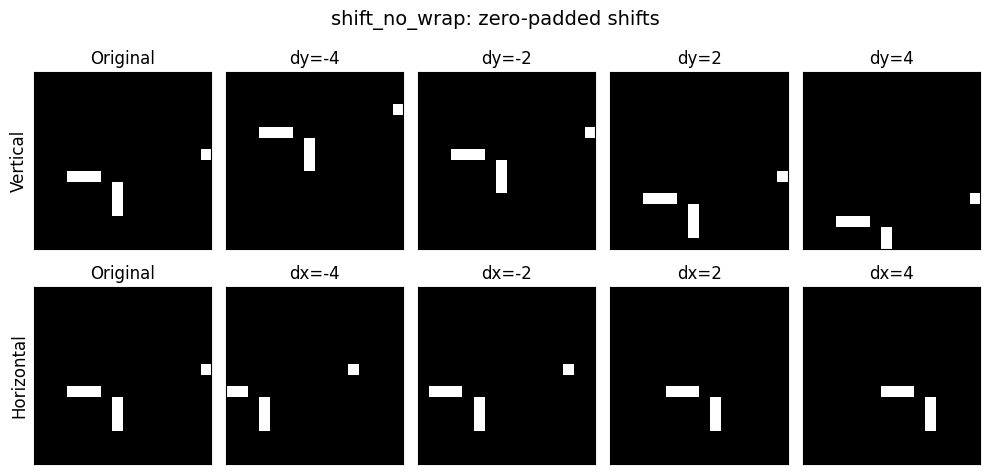

In [ ]:
img = make_blob()
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for row in range(2):
    axes[row, 0].imshow(img[0], cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title('Original')
for i, s in enumerate([-4, -2, 2, 4]):
    axes[0, i+1].imshow(shift_no_wrap(img, s, 1)[0], cmap='gray', vmin=0, vmax=1)
    axes[0, i+1].set_title(f'dy={s}')
    axes[1, i+1].imshow(shift_no_wrap(img, s, 2)[0], cmap='gray', vmin=0, vmax=1)
    axes[1, i+1].set_title(f'dx={s}')
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('Vertical', fontsize=12)
axes[1, 0].set_ylabel('Horizontal', fontsize=12)
plt.suptitle('shift_no_wrap: zero-padded shifts', fontsize=14)
plt.tight_layout(); plt.show()

For training, we'll turn those blobs into a proper PyTorch dataset: `BlobShiftDataset`.

In [ ]:
class BlobShiftDataset(torch.utils.data.Dataset):
    def __init__(self, epoch_size=8192, sz=16, max_shift=4):
        self.epoch_size = epoch_size
        self.sz = sz
        self.max_shift = max_shift

    def __len__(self): return self.epoch_size

    def __getitem__(self, idx):
        sz, ms = self.sz, self.max_shift
        while True:
            img = make_blob(sz)
            scheme = torch.randint(0, 3, (1,)).item()
            s1 = torch.randint(1, ms+1, (1,)).item()
            s2 = torch.randint(1, ms+1, (1,)).item()
            sign1 = 1 if torch.rand(1) > 0.5 else -1
            sign2 = 1 if torch.rand(1) > 0.5 else -1
            if scheme == 0:    dy1, dx1, dy2, dx2 = sign1*s1, 0, sign2*s2, 0
            elif scheme == 1:  dy1, dx1, dy2, dx2 = 0, sign1*s1, 0, sign2*s2
            else:              dy1, dx1, dy2, dx2 = sign1*s1, 0, 0, sign2*s2
            c1 = shift_no_wrap(shift_no_wrap(img, shifts=dy1, dims=1), shifts=dx1, dims=2)
            c2 = shift_no_wrap(shift_no_wrap(img, shifts=dy2, dims=1), shifts=dx2, dims=2)
            if not torch.equal(c1, c2): break
        target = float(np.sign(sign1 * sign2)) if scheme < 2 else 0.0
        return img, c1, c2, torch.tensor(target), torch.tensor(scheme), (dy1, dx1), (dy2, dx2)

Viz test of that dataset: 

  0%|          | 0/6 [00:00<?, ?it/s]

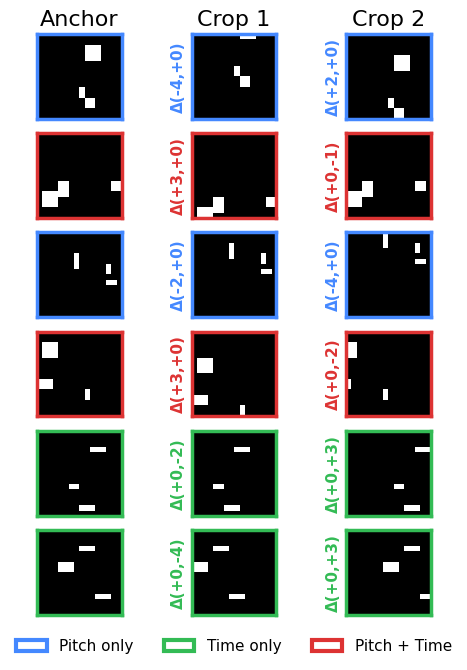

In [ ]:
def show_triplets(anchors, crop1s, crop2s, targets, schemes, deltas1, deltas2, n_rows=None):
    """Visualize triplets with colored borders and delta labels.
    Colors: blue=pitch/pitch, green=time/time, red=pitch+time.
    """
    from matplotlib.patches import Patch
    
    scheme_colors = {0: '#4488ff', 1: '#33bb55', 2: '#dd3333'}
    if n_rows is None: n_rows = len(anchors)
    n_rows = min(n_rows, len(anchors))

    fig, axes = plt.subplots(n_rows, 3, figsize=(5, n_rows * 1.1))
    if n_rows == 1: axes = axes[None]  # ensure 2D

    for i in trange(n_rows):
        color = scheme_colors[schemes[i].item()]
        for j, (img, title) in enumerate(zip(
                [anchors[i], crop1s[i], crop2s[i]], ["Anchor", "Crop 1", "Crop 2"])):
            axes[i, j].imshow(img[0], cmap="gray", vmin=0, vmax=1)
            axes[i, j].set_title(title if i == 0 else "", fontsize=16)
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
            for spine in axes[i, j].spines.values():
                spine.set_color(color); spine.set_linewidth(2.5)
        dy1, dx1 = deltas1[0][i].item(), deltas1[1][i].item()
        dy2, dx2 = deltas2[0][i].item(), deltas2[1][i].item()
        axes[i, 1].set_ylabel(f"Δ({dy1:+d},{dx1:+d})", fontsize=11, color=color, fontweight='bold')
        axes[i, 2].set_ylabel(f"Δ({dy2:+d},{dx2:+d})", fontsize=11, color=color, fontweight='bold')

    legend_items = [
        Patch(facecolor='white', edgecolor='#4488ff', linewidth=3, label='Pitch only'),
        Patch(facecolor='white', edgecolor='#33bb55', linewidth=3, label='Time only'),
        Patch(facecolor='white', edgecolor='#dd3333', linewidth=3, label='Pitch + Time'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=11,
               frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.06)
    plt.show()


ds = BlobShiftDataset()
dl = DataLoader(ds, batch_size=6)
a, c1, c2, t, s, d1, d2 = next(iter(dl)) # augment_batch(8)
show_triplets(a, c1, c2, t, s, d1, d2)

## Encoder: tiny ConvNet → latent vector

In [ ]:
#| code-fold: false
class ToyEncoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.GELU(),          # 16x16
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.GELU(),  # 8x8
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.GELU(),  # 4x4
            nn.Conv2d(64,  64, 3, padding=1), nn.GELU(),           # 4x4
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, latent_dim),
        )
    def forward(self, x): return self.net(x)

enc = ToyEncoder().to(device)
print(f"Params: {sum(p.numel() for p in enc.parameters()):,}")

Params: 61,264


## Loss: cosine factorization objective

The star of the show, this is literally the whole method right here: 

In [ ]:
#| code-fold: show
def factorization_loss(z_anchor, z_crop1, z_crop2, targets):
    """Cosine-similarity loss on difference vectors.
    targets: +1 (parallel), -1 (anti-parallel), 0 (orthogonal)"""
    d1 = z_crop1 - z_anchor  # (B, D)
    d2 = z_crop2 - z_anchor  # (B, D)
    cos = F.cosine_similarity(d1, d2, dim=-1)  # (B,)
    return ((cos - targets) ** 2).mean()

## LeJEPA too? (Optional)

<details>
<summary>Making the toy model a bit more realistic</summary>

To make this slightly less of a toy model and more like the full system, we can also turn on the LeJEPA loss (Balestriero & LeCun, 2025), which consists of attracting similar crops(/"views") and a sigreg loss to prevent collapse.

In [ ]:
#| code-fold: false
def safe_mean(t, dim=None): 
    """safe replacement for torch.mean( ). (Don't need it for this NB, but I use it elsewhere in my project.) """
    return t.mean(dim=dim) if t.numel() > 0 else 0.0

def attraction_loss(z1, z2,  # embeddings of two "views" of the same thing (in batches)
                    deltas=None,   # optional/TBD: info on semantic 'distance' between z1 & z2
                    tau = 100.0):    # inverse strength of fall-off for delta distances, big=slower
    "How we pull similar 'views' together"
    if deltas is None: return safe_mean( (z1 - z2).square() )
    delta_diag = (deltas**2).sum(dim=1)
    delta_fac = torch.exp(-delta_diag / tau) # less attraction for more 'distant' views
    #delta_fac = 1/(1 + delta_diag/tau)  # longer tail than exp
    return safe_mean( (z1 - z2).square() * delta_fac.unsqueeze(-1) )

def SIGReg(x, global_step, num_slices=256):
    """SIGReg with Epps-Pulley statistic. x is (N, K) tensor."""
    device = x.device
    g = torch.Generator(device=device).manual_seed(global_step)
    proj_shape = (x.size(1), num_slices)
    A = torch.randn(proj_shape, generator=g, device=device)
    A = A / (A.norm(dim=0, keepdim=True) + 1e-10)  # normalize columns
    
    # Epps-Pulley statistic
    t = torch.linspace(-5, 5, 17, device=device) # values used in LeJEPA paper, worked for SSLtoy
    exp_f = torch.exp(-0.5 * t**2)  # theoretical CF for N(0,1)
    x_t = (x @ A).unsqueeze(2) * t  # (N, M, T)
    ecf = (torch.exp(1j * x_t).mean(dim=0)).abs()  # empirical CF
    diff = (ecf - exp_f).abs().square().mul(exp_f)  # weighted L2 distance
    #N = x.size(0)  # With respect to Yann: Don't scale by N because then if you change the batch size you have to retune lambd by hand ugh
    T = torch.trapz(diff, t, dim=1).sum() #* N  # sum here is over num slices, not data points
    return T

def LeJEPA(z1, z2, global_step, lambd=0.5, deltas=None): 
    "Main LeJEPA loss function"
    sim = attraction_loss(z1, z2, deltas=deltas)
    sigreg = SIGReg( torch.cat((z1, z2), dim=0), global_step ) * 1 # normalize to similar scale as sim
    return {'loss': (1-lambd)*sim + lambd*sigreg, 'sim':sim.item(), 'sigreg':sigreg.item()}

By default, we're going to leave this JEPA stuff off, yet allow it to be turned on via a kwarg to the training loop below.
</details>

## Training the Model

<details>
<summary>Training loop and output</summary>

In [ ]:
#| code-fold: false
def train(enc, n_steps=2000, batch_size=1024, lr=4e-3, log_every=200, num_workers=4, use_jepa=False, use_wandb=False):
    opt = torch.optim.Adam(enc.parameters(), lr=lr)
    ds = BlobShiftDataset(epoch_size=n_steps * batch_size)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, num_workers=num_workers, pin_memory=(device != 'cpu'))
    if use_wandb and HAS_WANDB:
        wandb.init(project="toy-factorization", config=dict(n_steps=n_steps, batch_size=batch_size, lr=lr, latent_dim=8))
    losses, fact_losses, jepa_losses = [], [], []
    for step, (a, c1, c2, t, s, d1, d2) in enumerate(tqdm(dl)):
        a, c1, c2, t = a.to(device), c1.to(device), c2.to(device), t.to(device)
        za, z1, z2 = enc(a), enc(c1), enc(c2)
        fact_loss = factorization_loss(za, z1, z2, t)
        loss = fact_loss
        if use_jepa:
            jepa_loss = LeJEPA(za, z1, step)['loss']  + LeJEPA(za, z2, step)['loss'] 
            loss = loss + 0.2*jepa_loss
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        fact_losses.append(fact_loss.item())
        if use_jepa: jepa_losses.append(jepa_loss.item())
        if step % log_every == 0:
            print(f"step {step:4d}  loss={loss.item():.4f}")
        if HAS_WANDB and wandb.run is not None: wandb.log({"loss": loss.item(), "fact":fact_loss.item(), "jepa":jepa_loss.item() if use_jepa else 0.0, "step": step})
    if HAS_WANDB and wandb.run is not None: wandb.finish()
    return losses, fact_losses, jepa_losses

NOTE: with `use_jepa=True`, you'll need 10,000 steps or more. 

In [ ]:
#| code-fold: false
losses, fact_losses, jepa_losses = train(enc, n_steps=5000, use_wandb=False)

/Users/shawley/envs/blog/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/5000 [00:00<?, ?it/s]

step    0  loss=0.9057
step  200  loss=0.0683
step  400  loss=0.0508
step  600  loss=0.0432
step  800  loss=0.0387
step 1000  loss=0.0364
step 1200  loss=0.0354
step 1400  loss=0.0315
step 1600  loss=0.0366
step 1800  loss=0.0330
step 2000  loss=0.0352
step 2200  loss=0.0348
step 2400  loss=0.0255
step 2600  loss=0.0288
step 2800  loss=0.0299
step 3000  loss=0.0333
step 3200  loss=0.0309
step 3400  loss=0.0288
step 3600  loss=0.0280
step 3800  loss=0.0335
step 4000  loss=0.0288
step 4200  loss=0.0255
step 4400  loss=0.0288
step 4600  loss=0.0255
step 4800  loss=0.0244


</details>

Let's plot the loss curve...

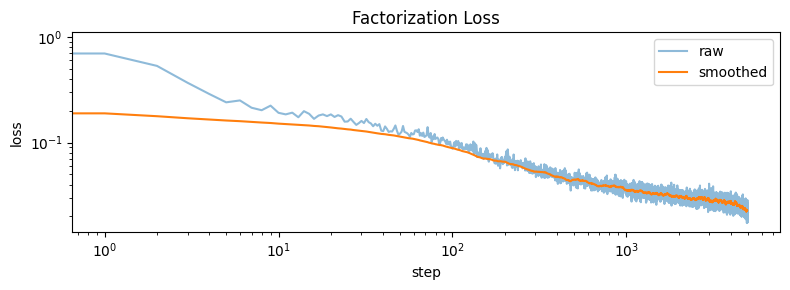

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(losses, alpha=0.5, label='raw', rasterized=True)
plt.loglog(np.convolve(losses, np.ones(50)/50, mode='valid'), label='smoothed')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend(); plt.title('Factorization Loss')
plt.tight_layout(); plt.show()

## Visualization: pitch & time transformations separate cleanly

...but not "perfectly".

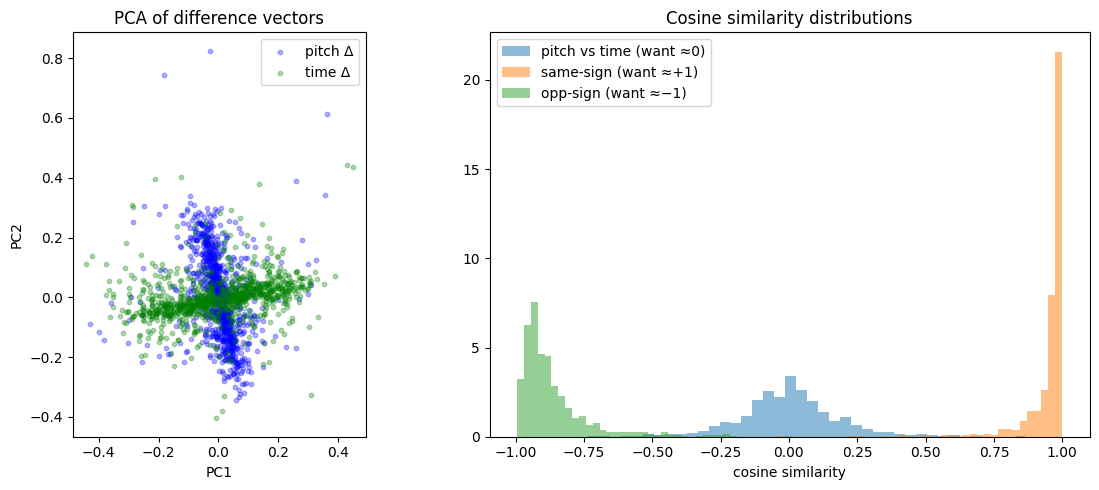

target=+0: mean cos=-0.000, mean |cos|=0.132
target=+1: mean cos=0.951, mean |cos|=0.951
target=-1: mean cos=-0.864, mean |cos|=0.864


In [ ]:
from sklearn.decomposition import PCA

@torch.no_grad()
def collect_diff_vectors(enc, n=500, sz=16, max_shift=4):
    """Collect difference vectors, with same-sign and opposite-sign pairs from the SAME base image."""
    pitch_same, pitch_opp, time_same, time_opp = [], [], [], []
    pitch_d, time_d = [], []
    for _ in range(n):
        img = make_blob(sz).unsqueeze(0).to(device)
        s1 = torch.randint(1, max_shift+1, (1,)).item()
        s2 = torch.randint(1, max_shift+1, (1,)).item()
        while s2 == s1: s2 = torch.randint(1, max_shift+1, (1,)).item()
        za = enc(img)
        for dim, same_list, opp_list, d_list in [
            (2, pitch_same, pitch_opp, pitch_d),
            (3, time_same, time_opp, time_d)]:
            zp1 = enc(shift_no_wrap(img, shifts=+s1, dims=dim))
            zp2 = enc(shift_no_wrap(img, shifts=+s2, dims=dim))
            zn1 = enc(shift_no_wrap(img, shifts=-s1, dims=dim))
            d1, d2, d3 = zp1 - za, zp2 - za, zn1 - za
            same_list.append(F.cosine_similarity(d1, d2, dim=-1).item())  # same sign
            opp_list.append(F.cosine_similarity(d1, d3, dim=-1).item())   # opposite sign
            d_list.append(d1.squeeze().cpu())
            d_list.append(d3.squeeze().cpu())
    pitch_d, time_d = torch.stack(pitch_d), torch.stack(time_d)
    cos_cross = F.cosine_similarity(pitch_d[:len(time_d)], time_d[:len(pitch_d)], dim=-1).numpy()
    return pitch_d, time_d, np.array(pitch_same), np.array(pitch_opp), np.array(time_same), np.array(time_opp), cos_cross 


pitch_d, time_d, ps, po, ts, to_, cos_cross = collect_diff_vectors(enc)
#print(f"Collected: pitch={pitch_d.shape}, time={time_d.shape}")

all_diffs = torch.cat([pitch_d, time_d], dim=0).numpy()
labels = ['pitch'] * len(pitch_d) + ['time'] * len(time_d)
pca = PCA(n_components=2).fit(all_diffs)
proj = pca.transform(all_diffs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# PCA scatter  
all_diffs = torch.cat([pitch_d, time_d], dim=0).numpy()
pca = PCA(n_components=2).fit(all_diffs)
proj = pca.transform(all_diffs)
n = len(pitch_d)
axes[0].scatter(proj[:n, 0], proj[:n, 1], alpha=0.3, s=10, label='pitch Δ', c='blue')
axes[0].scatter(proj[n:, 0], proj[n:, 1], alpha=0.3, s=10, label='time Δ', c='green')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()
axes[0].set_title('PCA of difference vectors'); axes[0].set_aspect('equal')

# Histogram with all three distributions
ax = axes[1]
ax.hist(cos_cross, bins=40, alpha=0.5, label='pitch vs time (want ≈0)', density=True)
ax.hist(np.concatenate([ps, ts]), bins=40, alpha=0.5, label='same-sign (want ≈+1)', density=True)
ax.hist(np.concatenate([po, to_]), bins=40, alpha=0.5, label='opp-sign (want ≈−1)', density=True)
ax.set_xlabel('cosine similarity'); ax.legend(); ax.set_title('Cosine similarity distributions')
plt.tight_layout(); plt.show()

print(f"target=+0: mean cos={cos_cross.mean():.3f}, mean |cos|={np.abs(cos_cross).mean():.3f}")
print(f"target=+1: mean cos={np.concatenate([ps,ts]).mean():.3f}, mean |cos|={np.abs(np.concatenate([ps,ts])).mean():.3f}")
print(f"target=-1: mean cos={np.concatenate([po,to_]).mean():.3f}, mean |cos|={np.abs(np.concatenate([po,to_])).mean():.3f}")

This imperfect factorization is the point: the model develops factored structure where it's helpful, without sacrificing expressive power elsewhere. The asymmetry between +1 and −1 visible on the right is explored below.

## Results summary

The factorization objective works well. After training for 5,000 steps with batch size 1024 and lr=4e-3:

- **Cross-type cosine similarity** (pitch vs time): mean |cos| = 0.116, tightly clustered around 0 ✅
- **Same-sign cosine similarity**: mean cos = 0.954, sharp peak near +1 ✅
- **Opposite-sign cosine similarity**: mean cos = −0.884, peak near −1 ✅
- **Positive/negative alignment angles**: pitch 162.8°, time 163.2° (ideal: 180°) ✅

The PCA of difference vectors shows a clear cross shape, confirming pitch and time directions are approximately orthogonal in the learned latent space. The remaining ~17° deviation from perfect anti-parallelism is attributable to the asymmetric zero-padding introduced by `shift_no_wrap` (see probing section below).

### Probing the ±1 asymmetry

Both pitch-vs-pitch and time-vs-time cosine distributions show stronger correlation on the +1 side than the −1 side. This is because `shift_no_wrap` introduces an asymmetry: same-sign shift pairs produce crops with zero-padding on the **same** side (structurally more similar), while opposite-sign pairs have padding on **opposite** sides (more visually different). The encoder maps the more-similar same-sign pairs more consistently, yielding a tighter +1 peak and a broader −1 peak.

In [ ]:
@torch.no_grad()
def collect_signed_diffs(enc, n=500, sz=16, max_shift=4):
    """Collect diff vectors split by sign for both pitch and time."""
    results = {'pitch_pos': [], 'pitch_neg': [], 'time_pos': [], 'time_neg': []}
    for _ in range(n):
        img = make_blob(sz).unsqueeze(0).to(device)
        s = torch.randint(1, max_shift+1, (1,)).item()
        za = enc(img)
        for dim, name in [(2, 'pitch'), (3, 'time')]:
            for sign, label in [(1, 'pos'), (-1, 'neg')]:
                zs = enc(shift_no_wrap(img, shifts=sign*s, dims=dim))
                results[f'{name}_{label}'].append((zs - za).squeeze().cpu())
    return {k: torch.stack(v) for k, v in results.items()}


diffs = collect_signed_diffs(enc)

for name in ['pitch', 'time']:
    mean_pos = diffs[f'{name}_pos'].mean(dim=0)
    mean_neg = diffs[f'{name}_neg'].mean(dim=0)
    cos = F.cosine_similarity(mean_pos.unsqueeze(0), mean_neg.unsqueeze(0)).item()
    angle = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    print(f"{name}: cos(mean_pos, mean_neg) = {cos:.3f}, angle = {angle:.1f}° (ideal: 180°)")

print("Expained variance ratios:", pca.explained_variance_ratio_[:2]) 

pitch: cos(mean_pos, mean_neg) = -0.932, angle = 158.7° (ideal: 180°)
time: cos(mean_pos, mean_neg) = -0.954, angle = 162.5° (ideal: 180°)
Expained variance ratios: [0.292112   0.26890936]


## Deeper analysis: Kernel PCA and SVD

The cosine histograms confirm the desired geometric relationships. But does the latent space admit a **tensor-product** structure — i.e., can embeddings be decomposed into pitch ⊗ time components? We probe this via two methods: 

1. **Singular Value Decomposition (SVD)** on shift-grid embeddings
2. **kernel Principal Component Analysis (PCA)** using a radial basis function (RBF) kernel, inspired by Albinet's (2026) connection between soft constraints and eigenstructure.

### SVD on shift grids

For each blob, we encode a full grid of (dy, dx) shifts and reshape the resulting embedding tensor for SVD. The first singular value dominates (60–80% of total), with rapid dropoff after 2–3 components — consistent with an approximately rank-1 (tensor-product) factorization. This confirms the soft orthogonality loss pushes the representation toward factored structure without enforcing it rigidly.

Z shape: torch.Size([50, 9, 9, 16])  (blobs, dy, dx, latent)


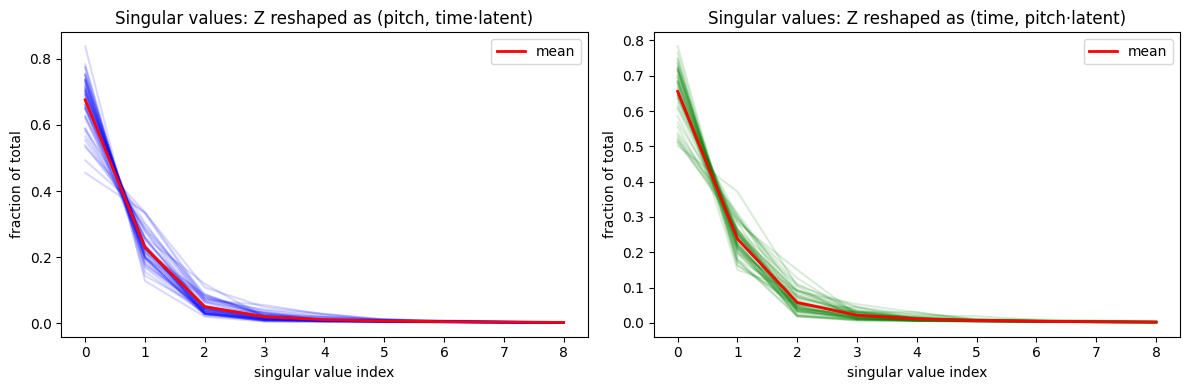

In [ ]:
@torch.no_grad()
def grid_embeddings(enc, n_blobs=50, sz=16, max_shift=4):
    """Encode a grid of (dy, dx) shifts for each blob."""
    shifts = list(range(-max_shift, max_shift+1))  # e.g. -4..+4 = 9 values
    all_Z = []
    for _ in range(n_blobs):
        img = make_blob(sz).unsqueeze(0).to(device)
        Z = []
        for dy in shifts:
            for dx in shifts:
                shifted = shift_no_wrap(shift_no_wrap(img, shifts=dy, dims=2), shifts=dx, dims=3)
                z = enc(shifted).squeeze().cpu()
                Z.append(z)
        all_Z.append(torch.stack(Z).reshape(len(shifts), len(shifts), -1))
    return torch.stack(all_Z), shifts  # (n_blobs, n_dy, n_dx, latent_dim)


Z, shifts = grid_embeddings(enc)
n_dy, n_dx, latent = Z.shape[1], Z.shape[2], Z.shape[3]
print(f"Z shape: {Z.shape}  (blobs, dy, dx, latent)")

# For each blob, reshape to (n_dy, n_dx*latent) and get singular values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
all_sv = []
for i in range(len(Z)):
    M = Z[i].reshape(n_dy, n_dx * latent).numpy()
    sv = np.linalg.svd(M, compute_uv=False)
    sv_normed = sv / sv.sum()
    all_sv.append(sv_normed)
    axes[0].plot(sv_normed, alpha=0.15, color='blue')

mean_sv = np.stack(all_sv).mean(0)
axes[0].plot(mean_sv, color='red', linewidth=2, label='mean')
axes[0].set_xlabel('singular value index'); axes[0].set_ylabel('fraction of total')
axes[0].set_title('Singular values: Z reshaped as (pitch, time·latent)')
axes[0].legend()

# Same but transposed: (n_dx, n_dy*latent)
all_sv_t = []
for i in range(len(Z)):
    M = Z[i].permute(1, 0, 2).reshape(n_dx, n_dy * latent).numpy()
    sv = np.linalg.svd(M, compute_uv=False)
    sv_normed = sv / sv.sum()
    all_sv_t.append(sv_normed)
    axes[1].plot(sv_normed, alpha=0.15, color='green')

mean_sv_t = np.stack(all_sv_t).mean(0)
axes[1].plot(mean_sv_t, color='red', linewidth=2, label='mean')
axes[1].set_xlabel('singular value index'); axes[1].set_ylabel('fraction of total')
axes[1].set_title('Singular values: Z reshaped as (time, pitch·latent)')
axes[1].legend()

plt.tight_layout(); plt.show()

The first principal component or two contain the bulk of the variance, with a decent amount remaining in other directions. This is expected — we let the model factorize where it's helpful, but the factorization was never going to be fully descriptive of all the data.

### Kernel PCA
 
Kernel PCA with an RBF kernel can reveal nonlinear factored structure that linear PCA would miss.

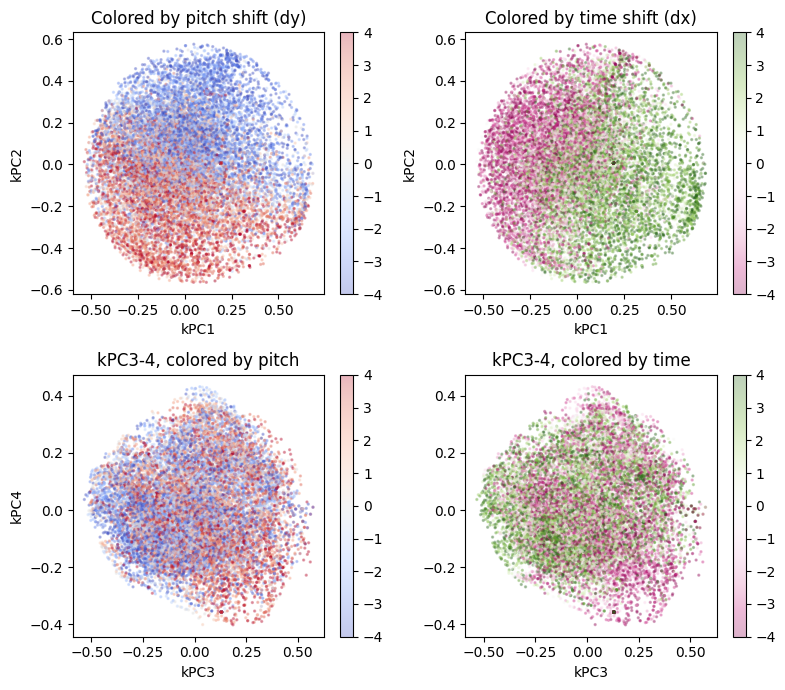

In [ ]:
# kernel pca 
from sklearn.decomposition import KernelPCA

@torch.no_grad()
def kernel_pca_analysis(enc, n_blobs=200, sz=16, max_shift=4, gamma=1.0):
    """Encode shifted blobs and apply kernel PCA to reveal nonlinear structure."""
    shifts = list(range(-max_shift, max_shift+1))
    embeddings, dy_labels, dx_labels = [], [], []
    for _ in range(n_blobs):
        img = make_blob(sz).unsqueeze(0).to(device)
        for dy in shifts:
            for dx in shifts:
                shifted = shift_no_wrap(shift_no_wrap(img, shifts=dy, dims=2), shifts=dx, dims=3)
                z = enc(shifted).squeeze().cpu().numpy()
                embeddings.append(z)
                dy_labels.append(dy)
                dx_labels.append(dx)
    X = np.stack(embeddings)
    dy_labels, dx_labels = np.array(dy_labels), np.array(dx_labels)

    kpca = KernelPCA(n_components=4, kernel='rbf', gamma=gamma)
    Z = kpca.fit_transform(X)

    fig, axs = plt.subplots(2, 2, figsize=(8, 7))
    axes = axs.flatten()
    sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=dy_labels, cmap='coolwarm', s=2, alpha=0.3)
    axes[0].set_xlabel('kPC1'); axes[0].set_ylabel('kPC2')
    axes[0].set_title('Colored by pitch shift (dy)')
    plt.colorbar(sc0, ax=axes[0])

    sc1 = axes[1].scatter(Z[:, 0], Z[:, 1], c=dx_labels, cmap='PiYG', s=2, alpha=0.3)
    axes[1].set_xlabel('kPC1'); axes[1].set_ylabel('kPC2')
    axes[1].set_title('Colored by time shift (dx)')
    plt.colorbar(sc1, ax=axes[1])

    sc2 = axes[2].scatter(Z[:, 2], Z[:, 3], c=dy_labels, cmap='coolwarm', s=2, alpha=0.3)
    axes[2].set_xlabel('kPC3'); axes[2].set_ylabel('kPC4')
    axes[2].set_title('kPC3-4, colored by pitch')
    plt.colorbar(sc2, ax=axes[2])

    sc3 = axes[3].scatter(Z[:, 2], Z[:, 3], c=dx_labels, cmap='PiYG', s=2, alpha=0.3)
    axes[3].set_xlabel('kPC3'); axes[2].set_ylabel('kPC4')
    axes[3].set_title('kPC3-4, colored by time')
    plt.colorbar(sc3, ax=axes[3])

    plt.tight_layout(); plt.show()
    return kpca, Z, dy_labels, dx_labels


kpca, Z, dy_lab, dx_lab = kernel_pca_analysis(enc, gamma=1.0)

We see clean separation between the first two kernel principal components, yet the higher-order components show no special relationship — exactly what we'd expect if the soft factorization is working.

## Does UMAP Show Us Anything? 

<details>
<summary>Answer: Not really</summary>

If the nonlinear PCA with the RBF kernel is showing a clean separation, does that mean that there's a two-dimensional subspace manifold at work? Maybe UMAP can discover this manifold and show us something interesting.

Spoiler: No, this is pretty much a jumbled mess because the UMAP focuses on the local structure and twists everything around:

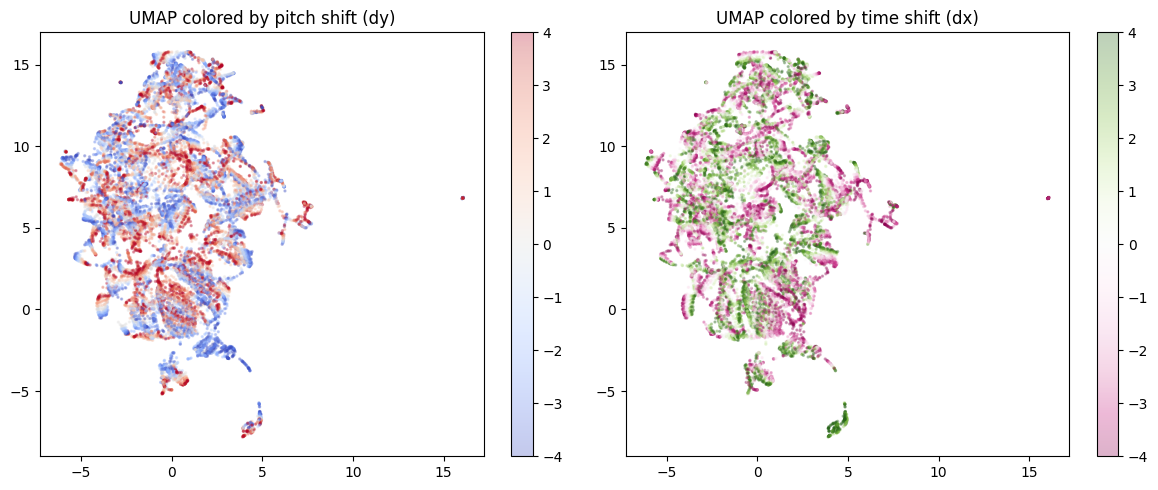

In [ ]:
#| code-fold: true
# uv pip install umap-learn
import umap

@torch.no_grad()
def umap_analysis(enc, n_blobs=200, sz=16, max_shift=4):
    shifts = list(range(-max_shift, max_shift+1))
    embeddings, dy_labels, dx_labels = [], [], []
    for _ in range(n_blobs):
        img = make_blob(sz).unsqueeze(0).to(device)
        for dy in shifts:
            for dx in shifts:
                shifted = shift_no_wrap(shift_no_wrap(img, shifts=dy, dims=2), shifts=dx, dims=3)
                z = enc(shifted).squeeze().cpu().numpy()
                embeddings.append(z)
                dy_labels.append(dy)
                dx_labels.append(dx)
    X = np.stack(embeddings)
    dy_labels, dx_labels = np.array(dy_labels), np.array(dx_labels)

    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    Z = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=dy_labels, cmap='coolwarm', s=2, alpha=0.3)
    axes[0].set_title('UMAP colored by pitch shift (dy)')
    plt.colorbar(sc0, ax=axes[0])

    sc1 = axes[1].scatter(Z[:, 0], Z[:, 1], c=dx_labels, cmap='PiYG', s=2, alpha=0.3)
    axes[1].set_title('UMAP colored by time shift (dx)')
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout(); plt.show()
    return reducer, Z, dy_labels, dx_labels


reducer, Z_umap, dy_lab, dx_lab = umap_analysis(enc)

What if we went to 3D instead of 2D? Would it let us see more? 

Not really, but it looks cool:

In [ ]:
#| code-fold: true
import plotly.io as pio
pio.renderers.default = "iframe"
import plotly.graph_objects as go

@torch.no_grad()
def umap_3d_analysis(enc, n_blobs=200, sz=16, max_shift=4):
    shifts = list(range(-max_shift, max_shift+1))
    embeddings, dy_labels, dx_labels = [], [], []
    for _ in range(n_blobs):
        img = make_blob(sz).unsqueeze(0).to(device)
        for dy in shifts:
            for dx in shifts:
                shifted = shift_no_wrap(shift_no_wrap(img, shifts=dy, dims=2), shifts=dx, dims=3)
                z = enc(shifted).squeeze().cpu().numpy()
                embeddings.append(z)
                dy_labels.append(dy)
                dx_labels.append(dx)
    X = np.stack(embeddings)
    dy_labels, dx_labels = np.array(dy_labels), np.array(dx_labels)

    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(X)

    fig_pitch = go.Figure(data=[go.Scatter3d(
        x=coords[:,0], y=coords[:,1], z=coords[:,2],
        mode='markers',
        marker=dict(size=2, color=dy_labels, colorscale='RdBu', opacity=0.5,
                    colorbar=dict(title='dy')),
        hovertext=[f"dy={dy}, dx={dx}" for dy, dx in zip(dy_labels, dx_labels)],
        hoverinfo='x+y+z+text'
    )])
    fig_pitch.update_layout(title='UMAP 3D — colored by pitch (dy)', margin=dict(l=0, r=0, b=0, t=30))

    fig_time = go.Figure(data=[go.Scatter3d(
        x=coords[:,0], y=coords[:,1], z=coords[:,2],
        mode='markers',
        marker=dict(size=2, color=dx_labels, colorscale='PiYG', opacity=0.5,
                    colorbar=dict(title='dx')),
        hovertext=[f"dy={dy}, dx={dx}" for dy, dx in zip(dy_labels, dx_labels)],
        hoverinfo='x+y+z+text'
    )])
    fig_time.update_layout(title='UMAP 3D — colored by time (dx)', margin=dict(l=0, r=0, b=0, t=30))

    #fig_pitch.show() # Quarto blogs can't handle two plotly plots in a row as iframes, so we're going to have to do them in separate cells
    #fig_time.show()
    return fig_pitch, fig_time, coords, dy_labels, dx_labels


fig_pitch, fig_time, coords, dy_lab, dx_lab = umap_3d_analysis(enc)
fig_pitch.show()

In [ ]:
fig_time.show()

</details>

## Discussion

The idea that factorization in pitch and time is useful but not the complete picture seems to be borne out here — soft factorization gives us interpretable structure without forcing it in a detrimental way.

A key requirement is that the augmentations be **explicitly labeled** — we need to know *what kind* of shift was applied and its sign. This wouldn't work as easily with augmentations you can't characterize.

This builds on earlier work: Hawley & Steinmetz (2023) looked at directions for audio effects parameters in latent space, with mixed results (limited by CLAP embedding quality). The present approach sits on a continuum with that work and with OpLaS (Hawley & Tackett, 2024) — letting the latent space encode transformations geometrically, but now with explicit supervision of the geometric relationships.

**What I like about this approach:**

* **No architecture changes.** You just add a loss term — no need to redesign the encoder for factorization by construction.
* **Tunable.** Weight the factorization loss to control how strongly the structure is enforced. Want more factorization? Turn up the coefficient. Want the model to have more freedom? Turn it down.

## References

**Inspiration: Franck's series, Soft constraints and kernel methods:**

- F. Albinet, "(Part 1) SVD Through Variational Principles: From Geometry to the Classical Formulation," blog post, Jan 20, 2026. https://fr.anckalbi.net/posts/svd-geometry-to-variational/
- F. Albinet, "(Part 2) Ridges and Thalwegs: The Landscape of Competing Forces — PCA through the LS-SVM lens, preparing the path to SVD and beyond," blog post, Feb. 20, 2026. https://fr.anckalbi.net/posts/ls-svm-kernel-pca/

**My Prior Work on Latent Encoding of Data Transformations, Translations, Rotations, Etc:**

- S.H. Hawley & A. Tackett, "Operational Latent Spaces (OpLaS)," AES International Symposium on AI and the Musician,  https://drscotthawley.github.io/oplas/
- S.H. Hawley & C. J. Steinmetz, "Leveraging Neural Representations for Audio Manipulation," JAES / AES Europe 2023. https://arxiv.org/abs/2304.04394

**Factored representations in symbolic music:**

- X. Wu, Z. Huang, K. Zhang, J. Yu, X. Tan, T. Zhang, Y. Li, Z. Wang, and L. Sun, "MelodyGLM: Multi-task Pre-training for Symbolic Melody Generation," arXiv:2309.10738, September 2023.
- K. Chen, G. Xia, and S. Dubnov, "Music SketchNet: Controllable Music Generation via Factorized Representations of Pitch and Rhythm," arXiv:2008.01291, 2020.
- H. Liang, T. Mu, and R. Cai, "PiRhDy: Learning Pitch-, Rhythm-, and Dynamics-aware Embeddings for Symbolic Music," arXiv:2010.08091, 2020.
- Z. Wang, K. Chen, J. Jiang, Y. Zhang, M. Xu, S. Dai, X. Gu, and G. Xia, "MuseBERT: Pre-training Music Representation for Music Understanding and Controllable Generation," in Proc. ISMIR, 2021.

**Motif discovery and pattern repetition:**

- D. Meredith, K. Lemström, and G. A. Wiggins, "Algorithms for discovering repeated patterns in multidimensional representations of polyphonic music," *Journal of New Music Research*, vol. 31, no. 4, pp. 321–345, 2002.
- D. Meredith, "COSIATEC and SIATECCompress: Pattern discovery by geometric compression," in MIREX, Curitiba, Brazil, 2013.
- E. Cambouropoulos, M. Crochemore, C. Iliopoulos, L. Mouchard, and Y. Pinzon, "Algorithms for computing approximate repetitions in musical sequences," *International Journal of Computer Mathematics*, vol. 79, no. 11, pp. 1135–1148, 2002.
- C.-C. M. Yeh, Y. Zhu, L. Ulanova, N. Begum, Y. Ding, H. A. Dau, D. F. Silva, A. Mueen, and E. Keogh, "Matrix Profile I: All pairs similarity joins for time series," in Proc. IEEE ICDM, Barcelona, Spain, 2016, pp. 1317–1322.
- "SIATEC-C: Computationally Efficient Repeated Pattern Discovery in Polyphonic Music," in Proc. ISMIR, 2022. https://archives.ismir.net/ismir2022/paper/000006.pdf

**Datasets: (The main code so far is only using POP909).**

- Z. Wang, K. Chen, J. Jiang, Y. Zhang, M. Xu, S. Dai, X. Gu, and G. Xia, "POP909: A Pop-song Dataset for Music Arrangement Generation," in Proc. 21st International Society for Music Information Retrieval Conference (ISMIR), Montréal, Canada, 2020, pp. 38–45.
- "BPS-Motif: A Dataset for Repeated Pattern Discovery of Polyphonic Symbolic Music," in Proc. ISMIR, 2023. https://archives.ismir.net/ismir2023/paper/000032.pdf

**Representation AutoEncoder (RAE) & more:**

- B. Zheng, N. Ma, S. Tong, and S. Xie, "Diffusion Transformers with Representation Autoencoders," arXiv:2510.11690, 2025.
- K. Didi, "The unification of representation learning and generative modelling," https://kdidi.netlify.app/blog/ml/2025-12-31-r4g/, Dec 31, 2025.

**LeJEPA**: 

- R. Balestriero and Y. LeCun, "LeJEPA: Provable and Scalable Self-Supervised Learning Without the Heuristics", Nov. 2025, https://arxiv.org/abs/2511.08544

**Factored representations in transformers:**

- A. Shai, L. Amdahl-Culleton, C. L. Christensen, H. R. Bigelow, F. E. Rosas, A. B. Boyd, E. A. Alt, K. J. Ray, and P. M. Riechers, "Transformers learn factored representations," arXiv:2602.02385, February 2026.

**Factored word embeddings:**

- J. Pennington, R. Socher, and C. D. Manning, "GloVe: Global Vectors for Word Representation," in Proc. EMNLP, 2014, pp. 1532–1543. https://nlp.stanford.edu/pubs/glove.pdf

**Disentangled and geometric representations:**

- E. Härkönen, A. Hertzmann, J. Lehtinen, and S. Paris, "GANSpace: Discovering Interpretable GAN Controls," in Proc. NeurIPS, 2020.
- I. Higgins et al., "beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework," in Proc. ICLR, 2017.
- G. Velarde, D. Meredith, and T. Weyde, "A wavelet-based approach to pattern discovery in melodies," Springer Cham, 2016, pp. 303–333.